<center>
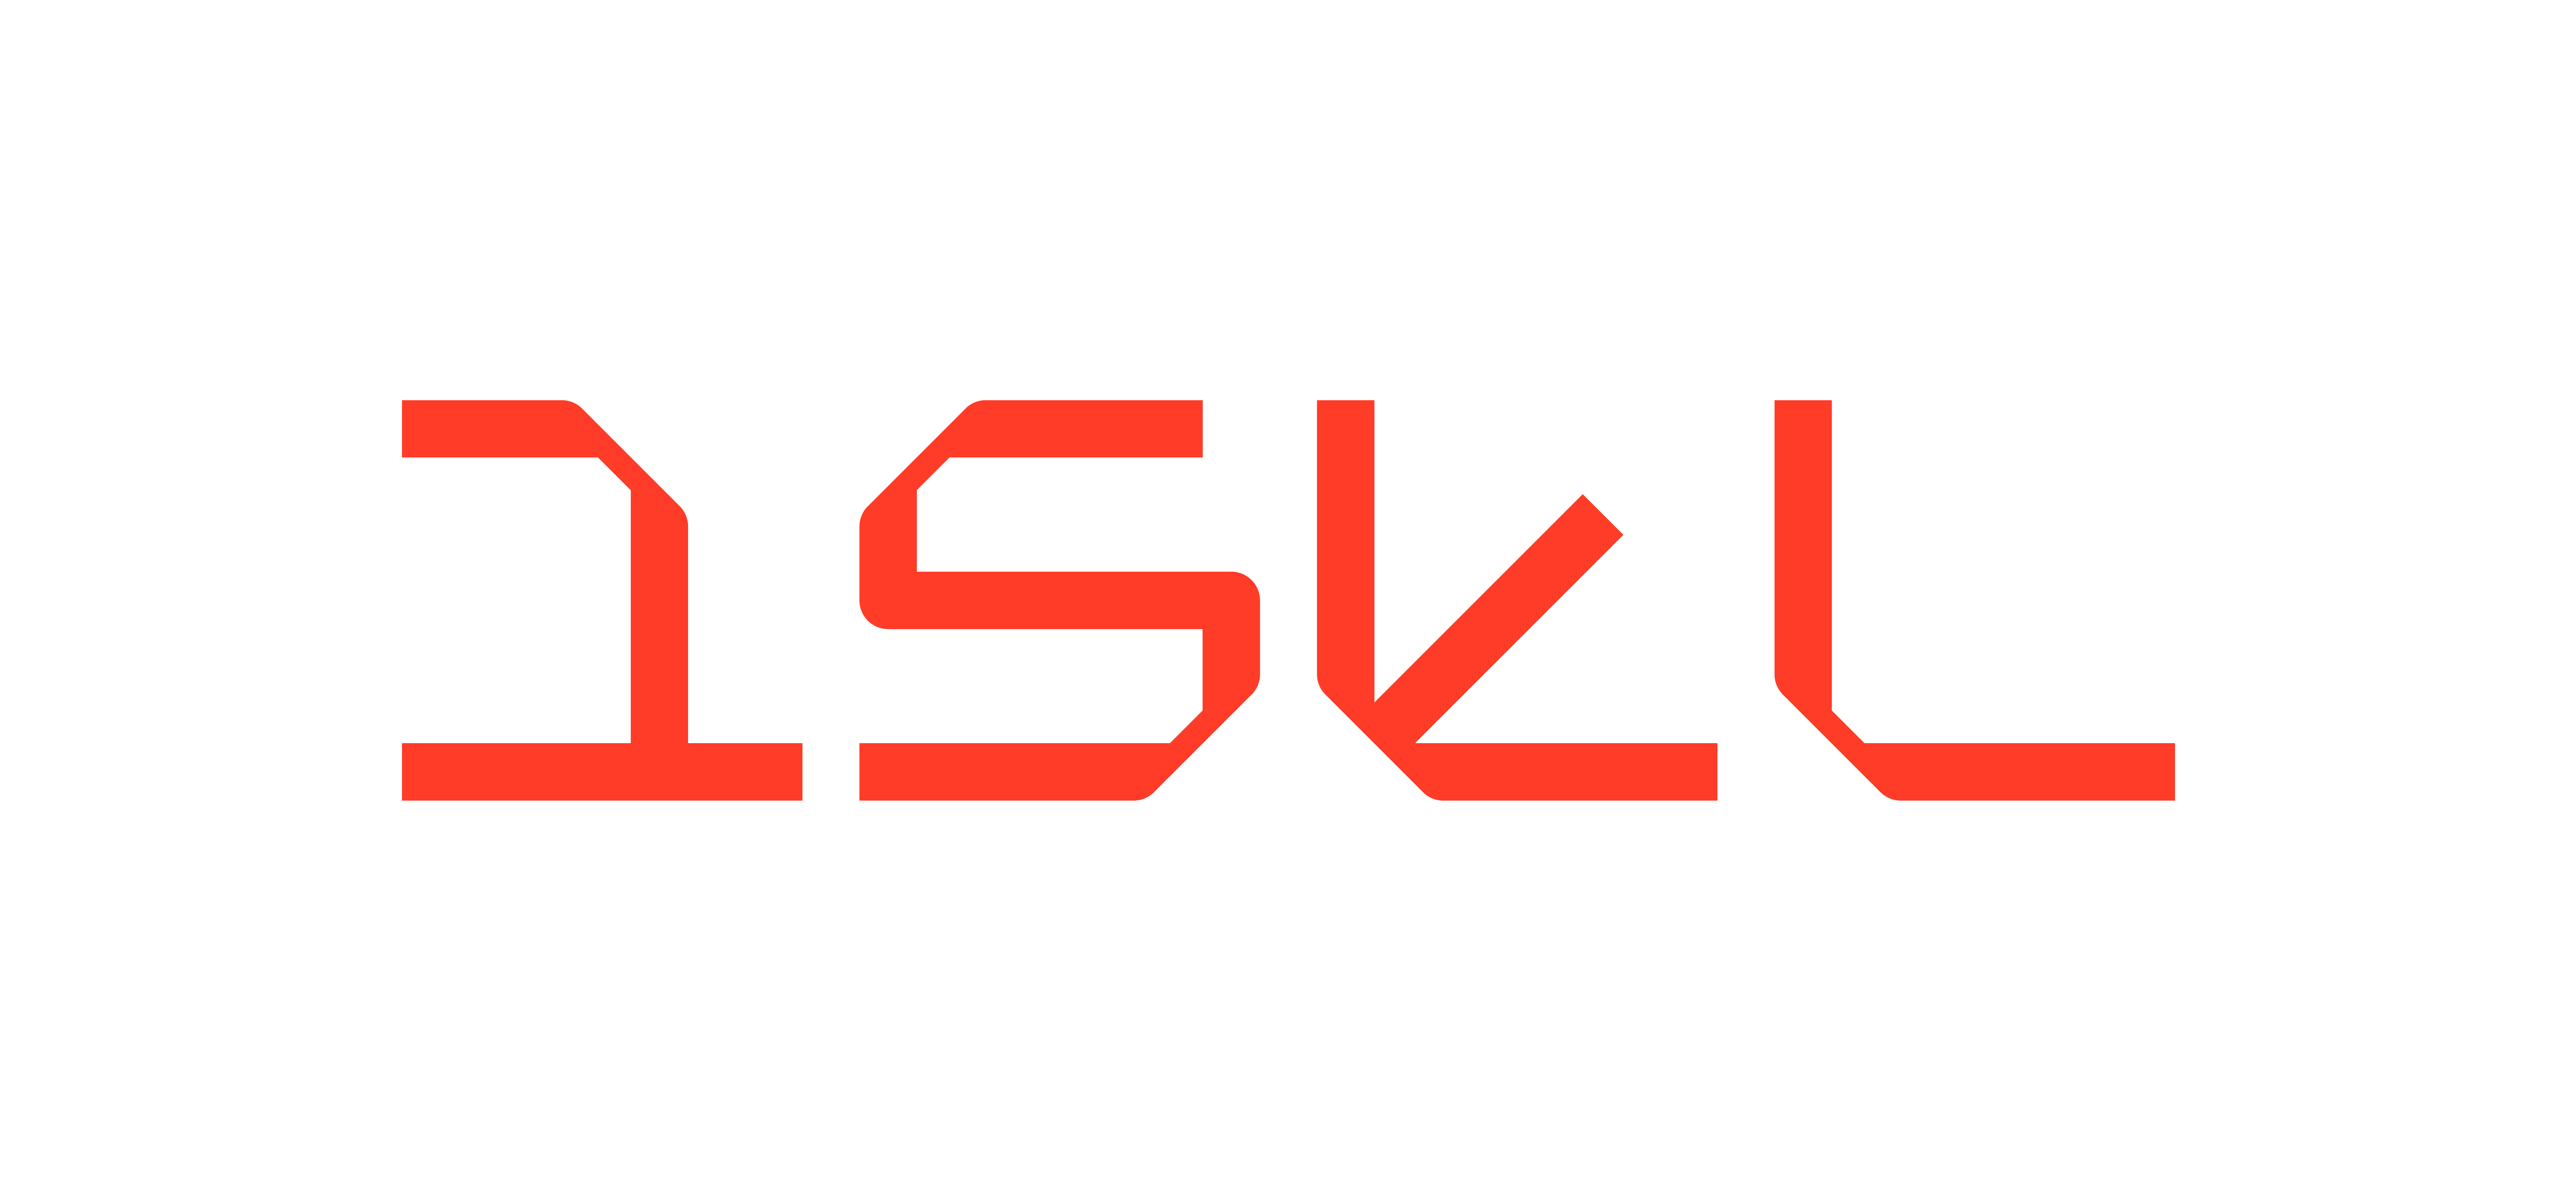
</center>

## <center><b>Instituto Superior de Engenharia de Lisboa<b></center>
### <center>Licenciatura em Engenharia Informática e Multimédia</center>
### <center><b>Processamento de Imagem e Visão</b><br>1º Semestre de 2025/2026</center>
#### <center><b>Trabalho Práctico 2</b></center>

<a id="inicio"></a>

<hr>
<br>
<center>Trabalho realizado por:<br>
• 46346 Inês Silva<br>
• 50274 Joana Araújo </center>
<br>

<br>

<center><b>Turma 51N ▪ Docente Nuno Silva</b></center><br>
<hr>

### <center>**Introdução**</center> <a class="anchor" id="chapter1"></a>

In [2]:
# importação das bibliotecas

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from collections import Counter
from scipy.spatial import distance as dist
from collections import OrderedDict
import time
import random
import ctypes

In [3]:
folder = "assets/media/"
folderXML = "assets/xml/"
frame_test = cv.imread(folder + "img_teste_4.png")

Frame capturado: (480, 640, 3)


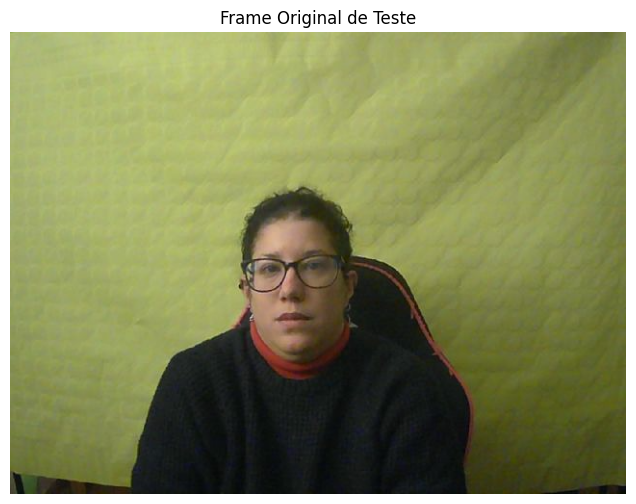

In [4]:
# Capturar um frame da webcam para experiência

cap = cv.VideoCapture(0)
ret, frame_test = cap.read()
cap.release()

if ret:
    # Espelha o frame para ser mais intuitivo
    frame_test = cv.flip(frame_test, 1)  
    print(f"Frame capturado: {frame_test.shape}")
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv.cvtColor(frame_test, cv.COLOR_BGR2RGB))
    plt.title("Frame Original de Teste")
    plt.axis('off')
    plt.show()
else:
    print("Erro ao capturar frame da webcam")

In [5]:
class Config:
    # Parâmetros de Jogo
    GAME_DURATION = 10
    
    # Parâmetros de Visão
    MIN_CONTOUR_AREA = 2000
    
    # Ranges YCrCb para pele (Luminância, Vermelho-Diferença, Azul-Diferença)
    SKIN_YCRCB_LOWER = np.array([0, 133, 77], dtype=np.uint8)
    SKIN_YCRCB_UPPER = np.array([255, 173, 127], dtype=np.uint8)
    
    # Ranges HSV para pele (Tonalidade, Saturação, Valor)
    # Nota: Hue 0-20 cobre os tons de pele avermelhados/laranja, excluindo o amarelo (>25)
    SKIN_HSV_LOWER = np.array([0, 20, 70], dtype=np.uint8)
    SKIN_HSV_UPPER = np.array([20, 255, 255], dtype=np.uint8)
    
    # Kernels Morfológicos
    KERNEL_ELLIPSE_5 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
    KERNEL_ELLIPSE_15 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (15, 15))

In [6]:
class VirtualBall:
    def __init__(self, x, y, radius=30, color=(0, 255, 255)):
        self.x = x
        self.y = y
        self.vx = random.randint(-5, 5)
        self.vy = random.randint(-5, 5)
        self.radius = radius
        self.color = color
        self.active = True
        
    def update(self, width, height):
        if not self.active: return
        self.x += self.vx
        self.y += self.vy
        
        # Colisão com bordas
        if self.x - self.radius < 0 or self.x + self.radius > width: self.vx *= -1
        if self.y - self.radius < 0 or self.y + self.radius > height: self.vy *= -1

    def draw(self, frame):
        if self.active:
            cv.circle(frame, (int(self.x), int(self.y)), self.radius, self.color, -1)
            cv.circle(frame, (int(self.x), int(self.y)), self.radius, (0,0,0), 2)
            # Brilho
            cv.circle(frame, (int(self.x - self.radius/3), int(self.y - self.radius/3)), int(self.radius/4), (255,255,255), -1)

    def check_collision_with_point(self, point, collision_radius=60):
        if not self.active: return False
        px, py = point
        dist = np.sqrt((self.x - px)**2 + (self.y - py)**2)
        
        if dist < self.radius + collision_radius:
            self.active = False
            return True
        return False

In [7]:
class AdvancedRegionDetector:
    def __init__(self):
        # Carregar Haar Cascade
        path = folderXML + 'haarcascade_frontalface_default.xml'
        self.face_cascade = cv.CascadeClassifier(path)
        if self.face_cascade.empty():
            self.face_cascade = cv.CascadeClassifier(cv.data.haarcascades + path)

    def get_contour_features(self, cnt, frame_height):
        area = cv.contourArea(cnt)
        if area == 0: return None
        
        x, y, w, h = cv.boundingRect(cnt)
        M = cv.moments(cnt)
        cx = int(M["m10"] / M["m00"]) if M["m00"] != 0 else 0
        cy = int(M["m01"] / M["m00"]) if M["m00"] != 0 else 0

        perimeter = cv.arcLength(cnt, True)
        if perimeter == 0: return None
        
        # Suavização para contagem de dedos
        epsilon = 0.01 * perimeter 
        approx = cv.approxPolyDP(cnt, epsilon, True)
        hull = cv.convexHull(approx, returnPoints=False)
        
        defects_count = 0
        fingertips = []
        # Adicionar o ponto mais alto como potencial ponta de dedo
        topmost = tuple(cnt[cnt[:, :, 1].argmin()][0])
        fingertips.append(topmost)

        if len(hull) > 3 and len(approx) > 3:
            try:
                defects = cv.convexityDefects(approx, hull)
                if defects is not None:
                    # Usar NumPy para vetorizar seria ideal, mas mantemos o loop simples por agora
                    for i in range(defects.shape[0]):
                        s, e, f, d = defects[i, 0]
                        start = tuple(approx[s][0])
                        end = tuple(approx[e][0])
                        far = tuple(approx[f][0])
                        
                        depth = d / 256.0
                        min_depth = max(5, frame_height * 0.05) 
                        
                        if depth > min_depth: 
                            a = np.sqrt((end[0] - start[0])**2 + (end[1] - start[1])**2)
                            b = np.sqrt((far[0] - start[0])**2 + (far[1] - start[1])**2)
                            c = np.sqrt((end[0] - far[0])**2 + (end[1] - far[1])**2)
                            angle = np.arccos((b**2 + c**2 - a**2) / (2*b*c)) * 57.29
                            
                            if angle <= 100:
                                defects_count += 1
                                fingertips.append(start)
                                fingertips.append(end)
            except: pass

        return {
            'cnt': approx, 'area': area, 'defects': defects_count, 
            'fingertips': fingertips, 'bbox': (x, y, w, h), 'center': (cx, cy)
        }

    def detect(self, mask, frame):
        h, w = frame.shape[:2]
        regions = {'head': None, 'hands': [], 'feet': []}
        
        # 1. Detetar Cara e Remover da Máscara
        gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
        faces = []
        if not self.face_cascade.empty():
            faces = self.face_cascade.detectMultiScale(gray, 1.1, 5)
        
        mask_body = mask.copy()
        
        if len(faces) > 0:
            # Maior cara
            fx, fy, fw, fh = max(faces, key=lambda r: r[2] * r[3])
            
            # Expandir caixa da cabeça (incluir orelhas/testa)
            infl_w = int(fw * 0.2)
            infl_h = int(fh * 0.4)
            nx = max(0, fx - infl_w)
            ny = max(0, fy - infl_h)
            nw = min(w, fx + fw + infl_w) - nx
            nh = min(h, fy + fh + int(fh*0.3)) - ny
            
            regions['head'] = {
                'center': (nx + nw//2, ny + nh//2),
                'bbox': (nx, ny, nw, nh)
            }
            # Apagar cabeça da máscara
            cv.rectangle(mask_body, (nx, ny), (nx+nw, ny+nh), 0, -1)
        
        # 2. Processar Resto do Corpo
        contours, _ = cv.findContours(mask_body, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv.contourArea(cnt) < Config.MIN_CONTOUR_AREA: continue
            
            feats = self.get_contour_features(cnt, h)
            if not feats: continue
            
            rel_y = feats['center'][1] / h
            
            if rel_y > 0.8:
                regions['feet'].append(feats)
            else:
                # Se não é pé nem cabeça (já removida), é mão
                # Validar se tem forma ou dedos
                if feats['defects'] > 0 or feats['area'] < (w*h)*0.15:
                    regions['hands'].append(feats)

        return regions

    def draw_debug(self, frame, regions):
        # Cabeça
        if regions['head']:
            x, y, w, h = regions['head']['bbox']
            cv.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 255), 2)
            cv.putText(frame, "HEAD", (x, y-10), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,255), 2)
        # Mãos
        for r in regions['hands']:
            cv.drawContours(frame, [r['cnt']], -1, (0, 255, 0), 2)
            for ft in r['fingertips']: # Pontos de colisão
                cv.circle(frame, ft, 5, (0, 0, 255), -1)
        # Pés
        for r in regions['feet']:
            x, y, w, h = r['bbox']
            cv.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        return frame

In [8]:
class ImageProcessor:
    @staticmethod
    def get_skin_mask(frame):
        """
        Segmentação Híbrida: YCrCb + HSV
        Remove o que não é pele com alta precisão.
        """
        # 1. YCrCb (Luminância, Crominância)
        ycrcb = cv.cvtColor(frame, cv.COLOR_BGR2YCrCb)
        mask_ycrcb = cv.inRange(ycrcb, Config.SKIN_YCRCB_LOWER, Config.SKIN_YCRCB_UPPER)
        
        # 2. HSV (Matiz, Saturação) - Ranges estritos para evitar amarelos
        hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
        mask_hsv = cv.inRange(hsv, Config.SKIN_HSV_LOWER, Config.SKIN_HSV_UPPER)
        
        # 3. Combinar com AND (Interseção) -> Tem de ser pele em AMBOS os espaços
        mask_skin = cv.bitwise_and(mask_ycrcb, mask_hsv)
        
        # 4. Limpeza Morfológica
        # Fechar buracos pequenos (Close) -> Remover ruído (Open)
        mask_clean = cv.morphologyEx(mask_skin, cv.MORPH_CLOSE, Config.KERNEL_ELLIPSE_5, iterations=3)
        mask_clean = cv.morphologyEx(mask_clean, cv.MORPH_OPEN, Config.KERNEL_ELLIPSE_5, iterations=2)
        
        # 5. Dilatar para consolidar o corpo
        mask_final = cv.dilate(mask_clean, Config.KERNEL_ELLIPSE_15, iterations=2)
        
        return mask_final

In [9]:
class GameApp:
    def __init__(self):
        self.cap = cv.VideoCapture(0)
        
        # Configurar Janela
        try:
            user32 = ctypes.windll.user32
            user32.SetProcessDPIAware()
            w, h = user32.GetSystemMetrics(0), user32.GetSystemMetrics(1)
        except: w, h = 1280, 720
            
        cv.namedWindow("Game", cv.WINDOW_NORMAL)
        cv.resizeWindow("Game", w - 100, h - 100)
        
        self.width = int(self.cap.get(cv.CAP_PROP_FRAME_WIDTH))
        self.height = int(self.cap.get(cv.CAP_PROP_FRAME_HEIGHT))
        
        self.detector = AdvancedRegionDetector()
        self.processor = ImageProcessor()
        
        self.state = "MENU" # MENU, GAME, GAMEOVER
        self.balls = []
        self.score = 0
        self.start_time = 0

    def start_game(self):
        self.state = "GAME"
        self.score = 0
        self.start_time = time.time()
        self.balls = [VirtualBall(random.randint(50, self.width-50), random.randint(50, self.height-50)) for _ in range(5)]

    def run(self):
        while True:
            ret, frame = self.cap.read()
            if not ret: break
            frame = cv.flip(frame, 1)
            key = cv.waitKey(1)
            # --- PROCESSAMENTO DE VISÃO ---
            # 1. Obter Máscara Robusta (Pele)
            mask = self.processor.get_skin_mask(frame)
            
            # 2. Detetar e Classificar Regiões
            regions = self.detector.detect(mask, frame)
            
            # 3. Desenhar Debug (Contornos)
            frame = self.detector.draw_debug(frame, regions)

            # --- LÓGICA DE ESTADOS ---
            if self.state == "MENU":
                """                 cv.putText(frame, "REALIDADE AUMENTADA - BOLA", (50, 100), cv.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
                cv.putText(frame, "Pressione SPACE para comecar", (50, 150), cv.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
                cv.putText(frame, "Modo: Detecao Auto de Pele", (50, 200), cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 1) """
                
                # Mostrar máscara pequena no canto para debug
                thumb_mask = cv.resize(mask, (160, 120))
                thumb_mask = cv.cvtColor(thumb_mask, cv.COLOR_GRAY2BGR)
                frame[self.height-130:self.height-10, 10:170] = thumb_mask
                cv.putText(frame, "Mask Debug", (10, self.height-135), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

                if key == 32: self.start_game()
                elif key == ord('q'): break

            elif self.state == "GAME":
                remaining = Config.GAME_DURATION - int(time.time() - self.start_time)
                if remaining <= 0: self.state = "GAMEOVER"
                
                # Atualizar Bolas e Colisões
                active_balls = 0
                for ball in self.balls:
                    ball.update(self.width, self.height)
                    ball.draw(frame)
                    
                    if ball.active:
                        active_balls += 1
                        hit = False
                        # Verificar colisão com TODAS as mãos
                        for hand in regions['hands']:
                            # Pontos de teste: Centro + Pontas dos dedos
                            points = [hand['center']] + hand['fingertips']
                            for pt in points:
                                radius = 60 if pt == hand['center'] else 30
                                if ball.check_collision_with_point(pt, radius):
                                    hit = True; break
                            if hit: break
                        
                        if hit: self.score += 1

                if active_balls == 0: # Respawn
                    self.balls = [VirtualBall(random.randint(50, self.width-50), random.randint(50, self.height-50)) for _ in range(5)]

                # HUD
                cv.putText(frame, f"Score: {self.score}", (30, 50), cv.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
                cv.putText(frame, f"Time: {remaining}", (self.width-150, 50), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

            elif self.state == "GAMEOVER":
                cv.putText(frame, "GAME OVER", (self.width//2-120, self.height//2), cv.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 3)
                cv.putText(frame, f"Final Score: {self.score}", (self.width//2-120, self.height//2+60), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
                cv.putText(frame, "Press R to Restart", (self.width//2-120, self.height//2+120), cv.FONT_HERSHEY_SIMPLEX, 0.8, (200, 200, 200), 2)
                
                if key == ord('r'): self.start_game()
                elif key == ord('q'): break

            cv.imshow("Game", frame)
            if key == ord('q'): break
        
        self.cap.release()
        cv.destroyAllWindows()

In [10]:
if __name__ == "__main__":
    app = GameApp()
    app.run()

### <center>**Conclusão**</center> <a class="anchor" id="chapter11"></a>


In [11]:
# guardado para bibliografia
# Source - https://stackoverflow.com/a
# Posted by spacether, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-28, License - CC BY-SA 4.0

user32 = ctypes.windll.user32
user32.SetProcessDPIAware()
[screen_w, screen_h] = [user32.GetSystemMetrics(0), user32.GetSystemMetrics(1)]

print([screen_w, screen_h])

[1920, 1080]
